### conda environment

`conda env create -n swaps_env_mini_AyS -f dev/wilhelm-lab/SWAPS/notebooks/environment_reduced2.yaml`

in environment_reduced2.yaml, commented in several cycles w/ updating the environment:
* python-graphviz
* deeplc
* jax
* distributed
* the version of jinja
* picked-group-fdr
* the version of dask & dask-expr
* added [complete] behind dask
* removed version number of bokeh 

```
conda activate swaps_env_mini_AyS
conda env update --file dev/wilhelm-lab/SWAPS/notebooks/environment_reduced2.yaml --prune
```
--> created environment "swaps"

In [1]:
from importlib import reload
from IPython.core.interactiveshell import InteractiveShell
%load_ext autoreload
InteractiveShell.ast_node_interactivity = "all"
import logging
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [2]:
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

2025-01-16 10:25:41,241 - numexpr.utils - INFO - Note: NumExpr detected 40 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2025-01-16 10:25:41,242 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.


In [3]:
pd.options.display.max_columns = 400

In [4]:
# restructured SWAPS repo (on my swa_for_xic_ayla branch) to be pip installable
# for this to work, had to install conda install -c conda-forge libstdcxx-ng=12 (created separate environment swaps_env_mini_AyS)


from SWAPS.utils.tools import load_mzml

/cmnfs/home/a.schroeder/miniconda3/envs/swaps_env_mini_AyS/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.25.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Run SWAPS with example config
/cmnfs/proj/ORIGINS/protMSD/maxquant/ScanByScan/utils/exp_configs/config_ayla_test.yaml bzw.  is reduced to my use case; a complete set of parameters can be found in the “singleton” config

```
RESULT_PATH: /cmnfs/proj/ORIGINS/SWAPS_exp/test_thermo/test_ayla
ADD_TIMESTAMP_TO_RESULT_PATH: true
DATA_PATH: /cmnfs/data/proteomics/origin/ayla_proteometools_subset/01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1.mzML
DEBUG: false
DICT_PICKLE_PATH: ''
EXPORT_DATA_HDF5_DIR: ''
MQ_REF_PATH: /cmnfs/data/proteomics/origin/ayla_proteometools_subset/TUM_first_pool_100_01_01_DDA-1h-R1-tryptic/evidence.txt
FILTER_REF_BY_RAW_FILE: ['01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1']
MQ_EXP_PATH: /cmnfs/data/proteomics/origin/ayla_proteometools_subset/TUM_first_pool_100_01_01_DDA-1h-R1-tryptic/evidence.txt
FILTER_EXP_BY_RAW_FILE: []
USE_IMS: false
N_CPU: 5
OPTIMIZATION:
  N_BLOCKS_BY_PEPT: 1
  N_BATCH: 5
PREPARE_DICT:
  DICT_PICKLE_PATH: ''
  FILTER_PRED_BY_RAW_FILE: ''
  FILTER_TRAIN_BY_RAW_FILE: ''
  GENERATE_DECOY: false
  ISO_MIN_AB_THRES: 0.01
  KEEP_MATCHED_PRECURSORS: false 
  MZ_BIN_DIGITS: 2
  RT_REF: exp
  RT_TOL: 0.01
RANDOM_SEED: 42
PEAK_SELECTION:
  ENABLE: false
RESULT_ANALYSIS:
  ENABLE: true
```

creates a new folder, name defined under `RESULT_PATH`, but adds a timestamp at the end

In [3]:
%autoreload 2
#!python /cmnfs/proj/ORIGINS/protMSD/maxquant/ScanByScan/sbs_runner_ims.py --config_path=/cmnfs/proj/ORIGINS/protMSD/maxquant/ScanByScan/utils/exp_configs/config_ayla_test.yaml
#!python /cmnfs/proj/ORIGINS/protMSD/maxquant/ScanByScan/sbs_runner_ims.py --config_path=/cmnfs/home/a.schroeder/dev/wilhelm-lab/SWAPS/utils/exp_configs/config_ayla_test.yaml
!python /cmnfs/home/a.schroeder/dev/wilhelm-lab/SWAPS/sbs_runner_ims.py --config_path=/cmnfs/home/a.schroeder/dev/wilhelm-lab/SWAPS/utils/exp_configs/config_ayla_test.yaml

/cmnfs/home/a.schroeder/miniconda3/envs/swaps/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
2025-01-14 16:23:07> merge with cfg file /cmnfs/home/a.schroeder/dev/wilhelm-lab/SWAPS/utils/exp_configs/config_ayla_test.yaml
2025-01-14 16:23:07> ==================Load data==================
2025-01-14 16:23:07> Reading mzML file
2025-01-14 16:23:09> Saving data to pickle file
2025-01-14 16:23:11> Filtered reference maxquant result by raw file: ['01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1']
2025-01-14 16:23:11> Using multiple GPUs, device is gpu
2025-01-14 16:23:11> maxquant_exp_df size: (1498, 59)
2025-01-14 16:23:11> maxquant_exp_df size after filter by raw file ['01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1']: (1498, 59)
2025-01-14 16:23:11> maxquant_exp_df size after removing matched precursors: (1447, 59)
2025-01-14 16:23:11> maxquan

# Check peptide activation

In [5]:
import sparse

# this is the results file with the activation values in newly created output folder (w/ time stamp)
# activation matrix (2D array) w/ dimensions: scans x peptides
pept_act = sparse.load_npz(
    #"/cmnfs/proj/ORIGINS/SWAPS_exp/test_thermo/test_ayla_20241219_131745_378483/results/activation/im_rt_pept_act_coo_peptbatch0.npz"
    "/cmnfs/data/proteomics/origin/ayla_proteometools_subset/test_swaps_20250114_162307_246083/results/activation/im_rt_pept_act_coo_peptbatch0.npz"
)
# convert to dense
pept_act_mat = pept_act.todense()
print(pept_act_mat.shape)

pept_act_mat

(2987, 1195)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
pept_act_sum_by_scan = pept_act_mat.sum(axis=1)
pept_act_sum_by_pept = pept_act_mat.sum(axis=0)

pept_act_mat has shape (n_ms1scans + 1, n_candidate + 1). The last row is a place holder so it is alway zero. To map the rows back to actual retention time value, you can use the mzML file. Row idx is the same as mzML scan index.

The first column is a place holder candidate since the candidates are identified by 'mz_rank', there is no rank 0 so column 0 always have zero intensity. You can map back the peptide using the dictionary from the result_path.

In [7]:
pept_act_df = pd.DataFrame(pept_act_mat)
print(pept_act_df.shape)

pept_act_df = pept_act_df.drop(pept_act_df.tail(1).index, axis=0) # last row
pept_act_df = pept_act_df.drop(0, axis=1) # first column

pept_act_df.columns.name = "precursor_id"
pept_act_df.index.name = "scan_id"


print(pept_act_df.shape)
display(pept_act_df.head())
display(pept_act_df.tail())

(2987, 1195)
(2986, 1194)


precursor_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,...,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023,1024,1025,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1043,1044,1045,1046,1047,1048,1049,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,1089,1090,1091,1092,1093,1094,1095,1096,1097,1098,1099,1100,1101,1102,1103,1104,1105,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115,1116,1117,1118,1119,1120,1121,1122,1123,1124,1125,1126,1127,1128,1129,1130,1131,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151,1152,1153,1154,1155,1156,1157,1158,1159,1160,1161,1162,1163,1164,1165,1166,1167,1168,1169,1170,1171,1172,1173,1174,1175,1176,1177,1178,1179,1180,1181,1182,1183,1184,1185,1186,1187,1188,1189,1190,1191,1192,1193,1194
scan_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

precursor_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,...,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023,1024,1025,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1043,1044,1045,1046,1047,1048,1049,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,1089,1090,1091,1092,1093,1094,1095,1096,1097,1098,1099,1100,1101,1102,1103,1104,1105,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115,1116,1117,1118,1119,1120,1121,1122,1123,1124,1125,1126,1127,1128,1129,1130,1131,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151,1152,1153,1154,1155,1156,1157,1158,1159,1160,1161,1162,1163,1164,1165,1166,1167,1168,1169,1170,1171,1172,1173,1174,1175,1176,1177,1178,1179,1180,1181,1182,1183,1184,1185,1186,1187,1188,1189,1190,1191,1192,1193,1194
scan_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65778.300722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,993885.818606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.863125e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,604177.685987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2982,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [8]:
pept_act_df_long = pept_act_df.stack().reset_index()
pept_act_df_long = pept_act_df_long.rename(columns={0: "activation"})

print(pept_act_df_long.shape)
display(pept_act_df_long.head())

(3565284, 3)


,scan_id,precursor_id,activation
0,0,1,0.0
1,0,2,0.0
2,0,3,0.0
3,0,4,0.0
4,0,5,0.0


In [9]:
# Load mzML file to map the scan index to the matrix --> get RT for the particular scan_id

mzml = load_mzml(
    "/cmnfs/data/proteomics/origin/ayla_proteometools_subset/01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1.mzML", 
    unify_format=True
)
print(mzml.shape)
display(mzml.head())
display(mzml.tail())

2025-01-16 10:25:48,317 - SWAPS.utils.tools - INFO - Reading mzML file
2025-01-16 10:25:50,919 - SWAPS.utils.tools - INFO - Saving data to pickle file


(2986, 8)


,Id,mslev,bpmz,MaxIntensity,Time_minute,mzarray,intarray,MS1_frame_idx
0,0,1,401.923645,2018264.250,0.001460,"[360.6346130371094, 360.8634033203125, 360.890...","[2541.843017578125, 7462.435546875, 7152.36035...",0
1,1,1,401.923523,2076548.750,0.007541,"[360.3759460449219, 360.8625183105469, 360.888...","[2863.816162109375, 3620.710205078125, 6307.36...",1
2,2,1,401.923584,2059200.625,0.014484,"[360.3743896484375, 360.40264892578125, 360.42...","[3163.982177734375, 4262.57958984375, 4774.449...",2
3,3,1,401.923553,2014930.125,0.020563,"[359.9998474121094, 360.4039306640625, 360.420...","[2999.219482421875, 5874.11328125, 2795.478759...",3
4,4,1,401.923615,1999425.875,0.027653,"[360.3739318847656, 360.4037170410156, 360.863...","[3266.89306640625, 3074.690673828125, 5196.136...",4


,Id,mslev,bpmz,MaxIntensity,Time_minute,mzarray,intarray,MS1_frame_idx
2981,2981,1,383.197266,89810560.0,59.849289,"[368.77069091796875, 369.2499084472656, 369.76...","[1004836.8125, 553828.75, 3140476.0, 1045946.5...",2981
2982,2982,1,411.203552,30059242.0,59.883528,"[360.7752990722656, 368.6939392089844, 369.250...","[328957.84375, 292272.28125, 3470814.75, 52680...",2982
2983,2983,1,1239.734131,10774142.0,59.916508,"[365.12872314453125, 369.24908447265625, 369.7...","[243676.40625, 453974.25, 175894.5625, 281780....",2983
2984,2984,1,984.651794,10775873.0,59.949604,"[361.2527770996094, 364.2597351074219, 364.296...","[228248.78125, 220204.484375, 313329.75, 13179...",2984
2985,2985,1,482.265900,14907719.0,59.982815,"[361.2525939941406, 364.2960510253906, 367.252...","[295414.0, 133722.984375, 332018.28125, 119416...",2985


In [10]:
pept_act_df_long_RT = pept_act_df_long.merge(
    mzml,
    left_on="scan_id",
    right_on="Id",
)
print(pept_act_df_long.shape, mzml.shape, pept_act_df_long_RT.shape)
display(pept_act_df_long_RT.head())

(3565284, 3) (2986, 8) (3565284, 11)


,scan_id,precursor_id,activation,Id,mslev,bpmz,MaxIntensity,Time_minute,mzarray,intarray,MS1_frame_idx
0,0,1,0.0,0,1,401.923645,2018264.25,0.00146,"[360.6346130371094, 360.8634033203125, 360.890...","[2541.843017578125, 7462.435546875, 7152.36035...",0
1,0,2,0.0,0,1,401.923645,2018264.25,0.00146,"[360.6346130371094, 360.8634033203125, 360.890...","[2541.843017578125, 7462.435546875, 7152.36035...",0
2,0,3,0.0,0,1,401.923645,2018264.25,0.00146,"[360.6346130371094, 360.8634033203125, 360.890...","[2541.843017578125, 7462.435546875, 7152.36035...",0
3,0,4,0.0,0,1,401.923645,2018264.25,0.00146,"[360.6346130371094, 360.8634033203125, 360.890...","[2541.843017578125, 7462.435546875, 7152.36035...",0
4,0,5,0.0,0,1,401.923645,2018264.25,0.00146,"[360.6346130371094, 360.8634033203125, 360.890...","[2541.843017578125, 7462.435546875, 7152.36035...",0


In [11]:
# Load dictionary (maxquant_result_ref) to map the precursor peptide identity to the matrix
maxquant_ref = pd.read_pickle(
    "/cmnfs/data/proteomics/origin/ayla_proteometools_subset/test_swaps_20250114_162307_246083/maxquant_result_ref.pkl"
)
print(maxquant_ref.shape)
display(maxquant_ref.head())
# mz_rank is the column that can be used for mapping candidate (precursors)

(1194, 81)


,Sequence,Length,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score Diffs,Oxidation (M),Missed cleavages,Proteins,Leading proteins,Leading razor protein,Type,Raw file,Experiment,MS/MS m/z,Charge,m/z,Mass,Resolution,Uncalibrated - Calibrated m/z [ppm],Uncalibrated - Calibrated m/z [Da],Mass Error [ppm],Mass Error [Da],Uncalibrated Mass Error [ppm],Uncalibrated Mass Error [Da],Max intensity m/z 0,Retention time,Retention length,Calibrated retention time,Calibrated retention time start,Calibrated retention time finish,Retention time calibration,Match time difference,Match m/z difference,Match q-value,Match score,Number of data points,Number of scans,Number of isotopic peaks,PIF,Fraction of total spectrum,Base peak fraction,PEP,MS/MS Count,MS/MS Scan Number,Score,Delta score,Combinatorics,Intensity,Reverse,Potential contaminant,id,Protein group IDs,Peptide ID,Mod. peptide ID,MS/MS IDs,Best MS/MS,AIF MS/MS IDs,Oxidation (M) site IDs,source,Time_minute_center_exp,MS1_frame_idx_center_exp,Time_minute_left_exp,MS1_frame_idx_left_exp,Time_minute_right_exp,MS1_frame_idx_right_exp,RT_search_left,RT_search_right,RT_search_center,Time_minute_center_ref,MS1_frame_idx_center_ref,Time_minute_left_ref,MS1_frame_idx_left_ref,Time_minute_right_ref,MS1_frame_idx_right_ref,IsoMZ,IsoAbundance,mz_rank,mz_bin,mz_length,pept_batch_idx
0,HSAGSGAEESNSSSTVQK,18,Unmodified,_HSAGSGAEESNSSSTVQK_,NaN,NaN,0,0,TUM_first_pool_100,TUM_first_pool_100,TUM_first_pool_100,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,881.8992,2,881.895551,1761.77655,33264.77,3.2033,0.002825,-0.59394,-0.000524,2.6093,0.002301,881.895247,9.2470,0.29307,9.2470,9.129100,9.422200,0.000000e+00,NaN,NaN,NaN,NaN,51.0,18.0,4.0,0.931814,0.004134,0.047162,9.186500e-03,1,1863,51.524,51.524,1,1915100.0,NaN,NaN,549,10,336,349,2111,2111,NaN,NaN,both,9.249557,1434.0,9.122148,1429.0,9.419170,1448.0,9.119100,9.432200,9.2470,9.249557,1434,9.122148,1429,9.435966,1450,"[881.896099294755, 882.394616742355, 882.39777...","[0.40151937597980825, 0.03375647811570961, 0.2...",654,881.90,8,0
1,HSAGSGAEESNSSSTVQK,18,Unmodified,_HSAGSGAEESNSSSTVQK_,NaN,NaN,0,0,TUM_first_pool_100,TUM_first_pool_100,TUM_first_pool_100,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,588.2675,3,588.266126,1761.77655,39642.33,1.8291,0.001076,0.22157,0.000130,2.0507,0.001206,588.266516,9.2401,0.39885,9.2401,9.116800,9.515700,0.000000e+00,NaN,NaN,NaN,NaN,101.0,31.0,6.0,0.936447,0.018548,0.173674,1.396000e-15,4,1850,138.050,138.050,1,6354200.0,NaN,NaN,548,10,336,349,2107;2108;2109;2110,2107,NaN,NaN,both,9.249557,1434.0,9.111481,1428.0,9.521035,1461.0,9.106800,9.525700,9.2401,9.249557,1434,9.111481,1428,9.521035,1461,"[588.2666745405933, 588.5990195056601, 588.601...","[0.40147291623879966, 0.033752572159174404, 0....",123,588.27,8,0
2,DTENHTSHGDGRQEVTSR,18,Unmodified,_DTENHTSHGDGRQEVTSR_,NaN,NaN,0,1,TUM_first_pool_100,TUM_first_pool_100,TUM_first_pool_100,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,507.2304,4,507.229682,2024.88962,43155.46,1.7143,0.000870,0.90234,0.000458,2.6166,0.001327,507.230789,9.2380,0.65560,9.2380,9.116799,9.772399,9.536700e-07,NaN,NaN,NaN,NaN,84.0,54.0,4.0,0.770844,0.005750,0.071556,5.250700e-02,1,1881,24.481,24.481,1,1903400.0,NaN,NaN,257,10,150,154,1001,1001,NaN,NaN,both,9.249557,1434.0,9.111481,1428.0,9.762089,1483.0,9.106799,9.782399,9.2380,9.249557,1434,9.111481,1428,9.782741,1484,"[507.23023033584, 507.47948905964, 507.4810690...","[0.3488500555217261, 0.03825452703565939, 0.29...",50,507.23,9,0
3,HQPASASSTAASPAHPAK,18,Unmodified,_HQPASASSTAASPAHPAK_,NaN,NaN,0,0,TUM_first_pool_100,TUM_first_pool_100,TUM_first_pool_100,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,572.6222,3,572.620175,1714.83870,40978.89,1.8467,0.001057,1.13730,0.000651,2.9839,0.001709,572.620682,10.0

In [12]:
pept_act_df_long_RT_pept = pept_act_df_long_RT.merge(
    maxquant_ref,
    left_on="precursor_id",
    right_on="mz_rank",
)
print(pept_act_df_long.shape, pept_act_df_long_RT.shape, maxquant_ref.shape, pept_act_df_long_RT_pept.shape)
display(pept_act_df_long_RT_pept.head())

(3565284, 3) (3565284, 11) (1194, 81) (3565284, 92)


,scan_id,precursor_id,activation,Id,mslev,bpmz,MaxIntensity,Time_minute,mzarray,intarray,MS1_frame_idx,Sequence,Length,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score Diffs,Oxidation (M),Missed cleavages,Proteins,Leading proteins,Leading razor protein,Type,Raw file,Experiment,MS/MS m/z,Charge,m/z,Mass,Resolution,Uncalibrated - Calibrated m/z [ppm],Uncalibrated - Calibrated m/z [Da],Mass Error [ppm],Mass Error [Da],Uncalibrated Mass Error [ppm],Uncalibrated Mass Error [Da],Max intensity m/z 0,Retention time,Retention length,Calibrated retention time,Calibrated retention time start,Calibrated retention time finish,Retention time calibration,Match time difference,Match m/z difference,Match q-value,Match score,Number of data points,Number of scans,Number of isotopic peaks,PIF,Fraction of total spectrum,Base peak fraction,PEP,MS/MS Count,MS/MS Scan Number,Score,Delta score,Combinatorics,Intensity,Reverse,Potential contaminant,id,Protein group IDs,Peptide ID,Mod. peptide ID,MS/MS IDs,Best MS/MS,AIF MS/MS IDs,Oxidation (M) site IDs,source,Time_minute_center_exp,MS1_frame_idx_center_exp,Time_minute_left_exp,MS1_frame_idx_left_exp,Time_minute_right_exp,MS1_frame_idx_right_exp,RT_search_left,RT_search_right,RT_search_center,Time_minute_center_ref,MS1_frame_idx_center_ref,Time_minute_left_ref,MS1_frame_idx_left_ref,Time_minute_right_ref,MS1_frame_idx_right_ref,IsoMZ,IsoAbundance,mz_rank,mz_bin,mz_length,pept_batch_idx
0,0,1,0.0,0,1,401.923645,2018264.250,0.001460,"[360.6346130371094, 360.8634033203125, 360.890...","[2541.843017578125, 7462.435546875, 7152.36035...",0,ISLGEHEGGGK,11,Unmodified,_ISLGEHEGGGK_,NaN,NaN,0,0,JPT_RT_Peptide,JPT_RT_Peptide,JPT_RT_Peptide,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,361.8533,3,361.852489,1082.53564,50531.3,1.147,0.000415,0.72851,0.000264,1.8755,0.000679,361.852843,18.158,1.3973,18.158,17.874002,19.272002,-0.000002,NaN,NaN,NaN,NaN,105.0,41.0,5.0,0.913364,0.015454,0.956923,0.000002,6,10853,103.08,103.08,1,311900000.0,NaN,NaN,636,7,387,403,2423;2424;2425;2426;2427;2428,2427,NaN,NaN,both,18.157817,1738.0,17.857976,1729.0,19.287946,1772.0,17.864002,19.282002,18.158,18.157817,1738,17.857976,1729,19.287946,1772,"[361.85303736233, 362.18538232739667, 362.1874...","[0.5546088141764408, 0.028381646647732853, 0.2...",1,361.85,7,0
1,1,1,0.0,1,1,401.923523,2076548.750,0.007541,"[360.3759460449219, 360.8625183105469, 360.888...","[2863.816162109375, 3620.710205078125, 6307.36...",1,ISLGEHEGGGK,11,Unmodified,_ISLGEHEGGGK_,NaN,NaN,0,0,JPT_RT_Peptide,JPT_RT_Peptide,JPT_RT_Peptide,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,361.8533,3,361.852489,1082.53564,50531.3,1.147,0.000415,0.72851,0.000264,1.8755,0.000679,361.852843,18.158,1.3973,18.158,17.874002,19.272002,-0.000002,NaN,NaN,NaN,NaN,105.0,41.0,5.0,0.913364,0.015454,0.956923,0.000002,6,10853,103.08,103.08,1,311900000.0,NaN,NaN,636,7,387,403,2423;2424;2425;2426;2427;2428,2427,NaN,NaN,both,18.157817,1738.0,17.857976,1729.0,19.287946,1772.0,17.864002,19.282002,18.158,18.157817,1738,17.857976,1729,19.287946,1772,"[361.85303736233, 362.18538232739667, 362.1874...","[0.5546088141764408, 0.028381646647732853, 0.2...",1,361.85,7,0
2,2,1,0.0,2,1,401.923584,2059200.625,0.014484,"[360.3743896484375, 360.40264892578125, 360.42...","[3163.982177734375, 4262.57958984375, 4774.449...",2,ISLGEHEGGGK,11,Unmodified,_ISLGEHEGGGK_,NaN,NaN,0,0,JPT_RT_Peptide,JPT_RT_Peptide,JPT_RT_Peptide,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,361.8533,3,361.852489,1082.53564,50531.3,1.147,0.000415,0.72851,0.000264,1.8755,0.000679,361.852843,18.158,1.3973,18.158,17.874002,19.272002,-0.000002,NaN,NaN,NaN,NaN,105.0,41.0,5.0,0.913364,0.015454,0.956923,0.000002,6,10853,103.08,103.08,1,311900000.0,NaN,NaN,636,7,387,403,2423;2424;2425;2426;2427;2428,2427,NaN,NaN,both,18.157817,1738.0,17.857976,1729.0,19.2

In [13]:
# drop empty activation rows
pept_act_df_long_RT_pept_meaningful = pept_act_df_long_RT_pept[pept_act_df_long_RT_pept.activation != 0]
print(pept_act_df_long_RT_pept_meaningful.shape)
pept_act_df_long_RT_pept_meaningful.head()

(21594, 92)


,scan_id,precursor_id,activation,Id,mslev,bpmz,MaxIntensity,Time_minute,mzarray,intarray,MS1_frame_idx,Sequence,Length,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score Diffs,Oxidation (M),Missed cleavages,Proteins,Leading proteins,Leading razor protein,Type,Raw file,Experiment,MS/MS m/z,Charge,m/z,Mass,Resolution,Uncalibrated - Calibrated m/z [ppm],Uncalibrated - Calibrated m/z [Da],Mass Error [ppm],Mass Error [Da],Uncalibrated Mass Error [ppm],Uncalibrated Mass Error [Da],Max intensity m/z 0,Retention time,Retention length,Calibrated retention time,Calibrated retention time start,Calibrated retention time finish,Retention time calibration,Match time difference,Match m/z difference,Match q-value,Match score,Number of data points,Number of scans,Number of isotopic peaks,PIF,Fraction of total spectrum,Base peak fraction,PEP,MS/MS Count,MS/MS Scan Number,Score,Delta score,Combinatorics,Intensity,Reverse,Potential contaminant,id,Protein group IDs,Peptide ID,Mod. peptide ID,MS/MS IDs,Best MS/MS,AIF MS/MS IDs,Oxidation (M) site IDs,source,Time_minute_center_exp,MS1_frame_idx_center_exp,Time_minute_left_exp,MS1_frame_idx_left_exp,Time_minute_right_exp,MS1_frame_idx_right_exp,RT_search_left,RT_search_right,RT_search_center,Time_minute_center_ref,MS1_frame_idx_center_ref,Time_minute_left_ref,MS1_frame_idx_left_ref,Time_minute_right_ref,MS1_frame_idx_right_ref,IsoMZ,IsoAbundance,mz_rank,mz_bin,mz_length,pept_batch_idx
1730,1730,1,5.323533e+02,1730,1,467.722931,5038276.5,17.890847,"[360.2091369628906, 361.19677734375, 361.90518...","[47816.74609375, 58999.1484375, 63547.48828125...",1730,ISLGEHEGGGK,11,Unmodified,_ISLGEHEGGGK_,NaN,NaN,0,0,JPT_RT_Peptide,JPT_RT_Peptide,JPT_RT_Peptide,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,361.8533,3,361.852489,1082.53564,50531.3,1.147,0.000415,0.72851,0.000264,1.8755,0.000679,361.852843,18.158,1.3973,18.158,17.874002,19.272002,-0.000002,NaN,NaN,NaN,NaN,105.0,41.0,5.0,0.913364,0.015454,0.956923,0.000002,6,10853,103.08,103.08,1,311900000.0,NaN,NaN,636,7,387,403,2423;2424;2425;2426;2427;2428,2427,NaN,NaN,both,18.157817,1738.0,17.857976,1729.0,19.287946,1772.0,17.864002,19.282002,18.158,18.157817,1738,17.857976,1729,19.287946,1772,"[361.85303736233, 362.18538232739667, 362.1874...","[0.5546088141764408, 0.028381646647732853, 0.2...",1,361.85,7,0
1731,1731,1,2.663411e+04,1731,1,467.722748,6696641.5,17.925056,"[360.2093200683594, 360.7007141113281, 360.878...","[46555.390625, 24664.734375, 22293.447265625, ...",1731,ISLGEHEGGGK,11,Unmodified,_ISLGEHEGGGK_,NaN,NaN,0,0,JPT_RT_Peptide,JPT_RT_Peptide,JPT_RT_Peptide,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,361.8533,3,361.852489,1082.53564,50531.3,1.147,0.000415,0.72851,0.000264,1.8755,0.000679,361.852843,18.158,1.3973,18.158,17.874002,19.272002,-0.000002,NaN,NaN,NaN,NaN,105.0,41.0,5.0,0.913364,0.015454,0.956923,0.000002,6,10853,103.08,103.08,1,311900000.0,NaN,NaN,636,7,387,403,2423;2424;2425;2426;2427;2428,2427,NaN,NaN,both,18.157817,1738.0,17.857976,1729.0,19.287946,1772.0,17.864002,19.282002,18.158,18.157817,1738,17.857976,1729,19.287946,1772,"[361.85303736233, 362.18538232739667, 362.1874...","[0.5546088141764408, 0.028381646647732853, 0.2...",1,361.85,7,0
1732,1732,1,2.637420e+04,1732,1,467.722900,6922692.0,17.958048,"[360.68035888671875, 360.8749694824219, 361.19...","[44356.24609375, 44046.0234375, 52253.6796875,...",1732,ISLGEHEGGGK,11,Unmodified,_ISLGEHEGGGK_,NaN,NaN,0,0,JPT_RT_Peptide,JPT_RT_Peptide,JPT_RT_Peptide,MULTI-MSMS,01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1,TUM_first_pool_100_01_01-DDA-1h-R1-tryptic,361.8533,3,361.852489,1082.53564,50531.3,1.147,0.000415,0.72851,0.000264,1.8755,0.000679,361.852843,18.158,1.3973,18.158,17.874002,19.272002,-0.000002,NaN,NaN,NaN,NaN,105.0,41.0,5.0,0.913364,0.015454,0.956923,0.000002,6,10853,103.08,103.08,1,311900000.0,NaN,NaN,636,7,387,403,2423;2424;2425;2426;2427;2

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'mzml Time_minute')

Text(0, 0.5, 'maxquant_result_ref dict Retention time')

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'mzml Time_minute')

...

Text(0.5, 0, 'mzml Time_minute')

Text(0, 0.5, 'maxquant_result_ref dict Time_minute_left_ref')

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'mzml Time_minute')

Text(0, 0.5, 'maxquant_result_ref dict Time_minute_right_ref')

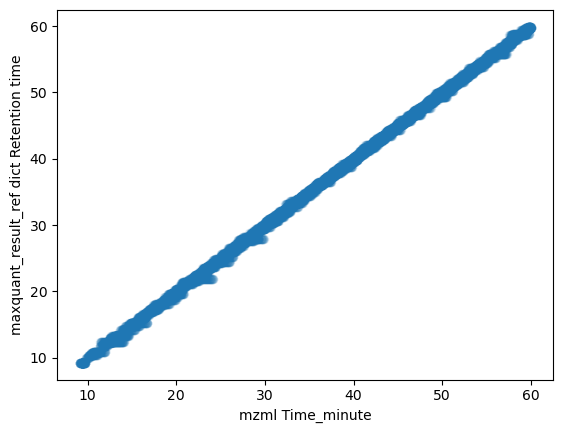

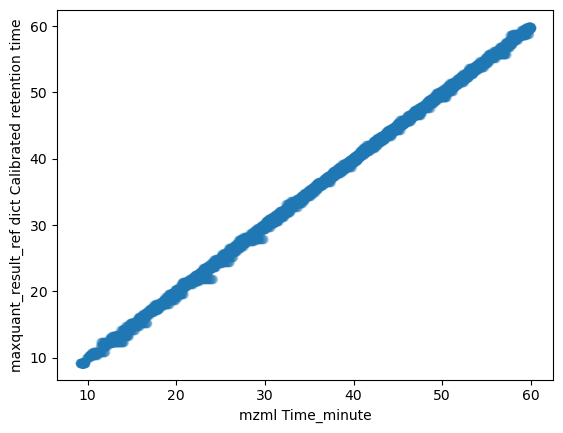

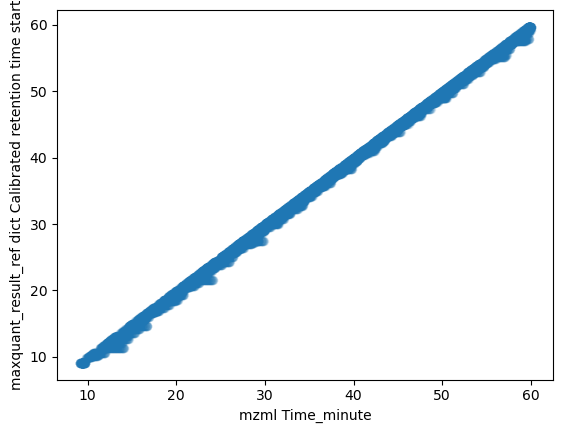

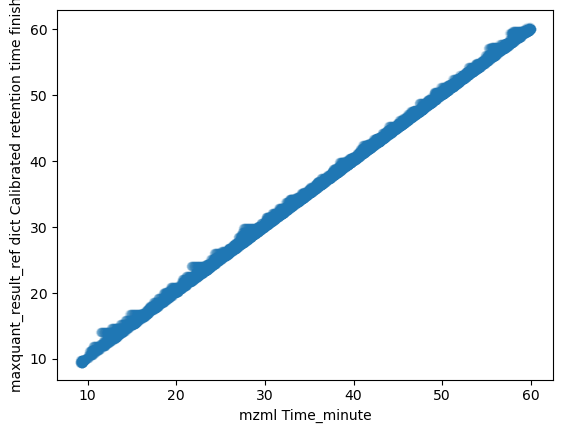

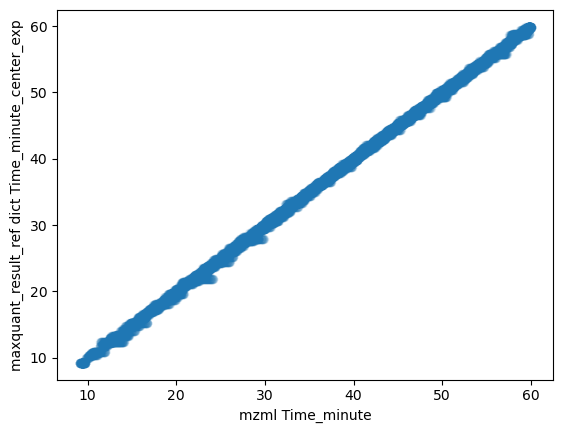

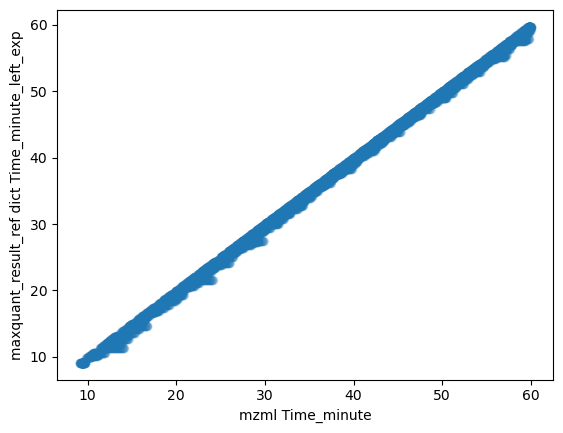

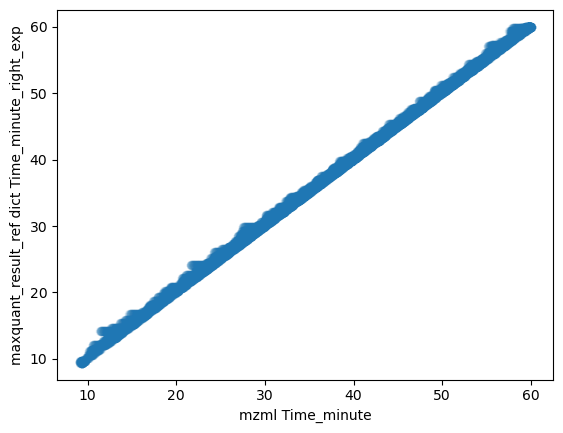

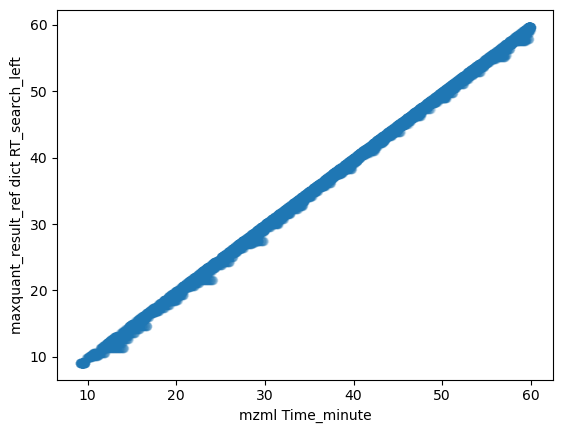

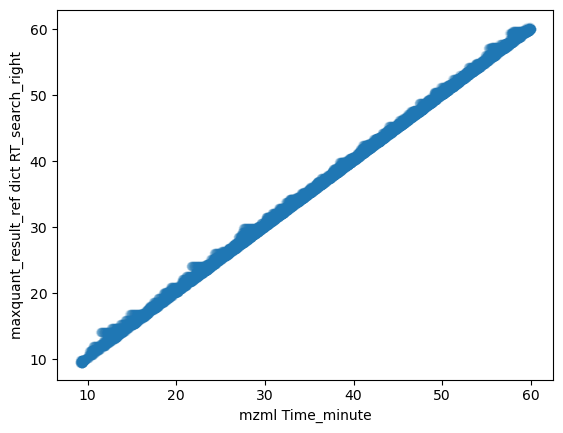

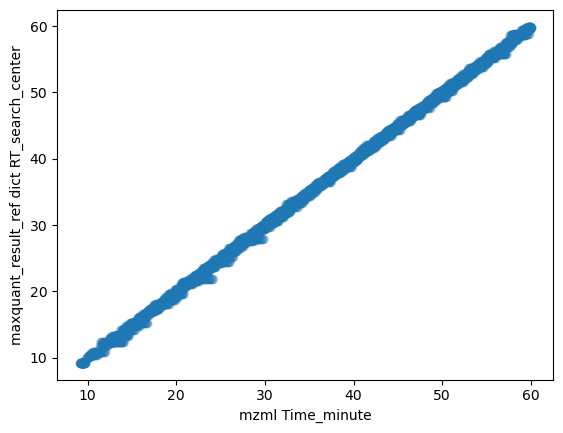

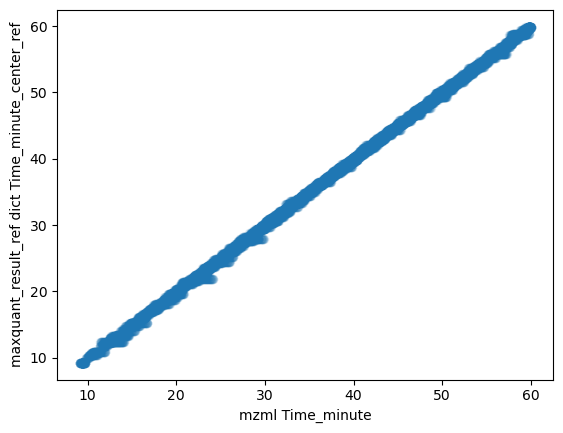

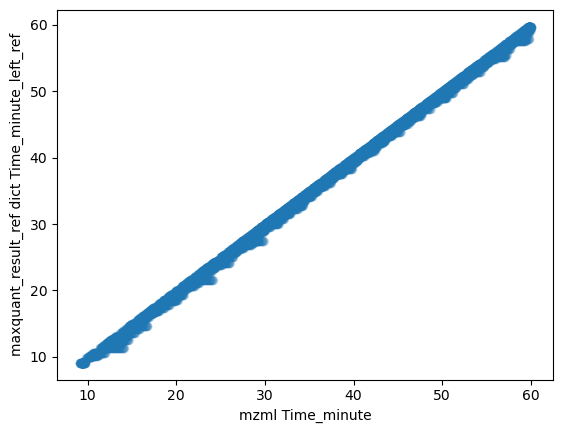

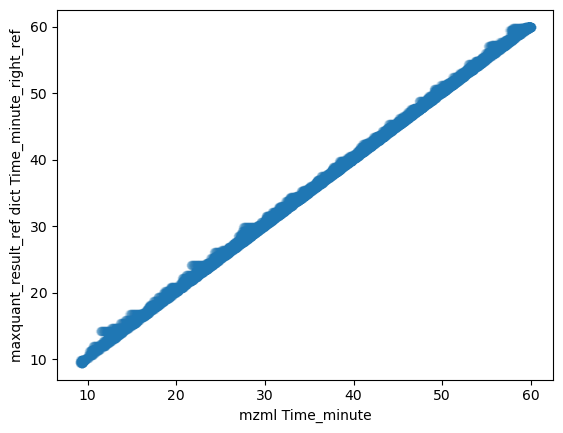

In [19]:
for dict_col in [
    "Retention time", "Calibrated retention time", "Calibrated retention time start", "Calibrated retention time finish", 
    "Time_minute_center_exp", "Time_minute_left_exp", "Time_minute_right_exp", "RT_search_left", "RT_search_right", "RT_search_center",
    "Time_minute_center_ref", "Time_minute_left_ref", "Time_minute_right_ref"
]:
    plt.figure()
    plt.scatter(
        pept_act_df_long_RT_pept_meaningful.Time_minute,
        pept_act_df_long_RT_pept_meaningful[dict_col],
        alpha=0.1
    )
    plt.xlabel("mzml Time_minute")
    plt.ylabel(f"maxquant_result_ref dict {dict_col}")

In [ ]:
plt.scatter(
    pept_act_df_long_RT_pept_meaningful.Time_minute,
    pept_act_df_long_RT_pept_meaningful["Retention time"],
    alpha=0.1
)
plt.xlabel("mzml time")
plt.ylabel("maxquant_result_ref dict time")

In [14]:
# save the long form for plotting & comparison w/ TRFP & biosaur2
pept_act_df_long_RT_pept_meaningful.to_parquet(
    "/cmnfs/data/proteomics/origin/ayla_proteometools_subset/test_swaps_20250114_162307_246083/activation_long_annot.parquet"
)

# Add MS1-extracted candidates to original table

In [ ]:
# Load dataframe w/ all putatively possible CS peaks from JSON file
"""
the file 01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1_mz.json contains the calculated "expected" m/z of other charge states together with rt_start & rt_end
It's content looks like this:
{'mz': 1013.4910277988012,
  'rt_start': 49.7349745229333,
  'rt_end': 50.1150526826667,
  'tolerance': 5,
  'tolerance_unit': 'ppm',
  'comment': '0_2'},
The 'comment' is used to be able to map the json entries back to the parsed biosaur output (<feature_group_id>_<charge>)
"""
df_from_json = pd.read_json(
  "/cmnfs/data/proteomics/origin/ayla_proteometools_subset/01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1_mz.json"
)
print(df_from_json.head())

# TODO wanna change read-in, cause comment is no longer as it should be

'\nthe file 01709a_GB1-TUM_first_pool_100_01_01-DDA-1h-R1_mz.json contains the calculated "expected" m/z of other charge states together with rt_start & rt_end\nIt\'s content looks like this:\n{\'mz\': 1013.4910277988012,\n  \'rt_start\': 49.7349745229333,\n  \'rt_end\': 50.1150526826667,\n  \'tolerance\': 5,\n  \'tolerance_unit\': \'ppm\',\n  \'comment\': \'0_2\'},\nThe \'comment\' is used to be able to map the json entries back to the parsed biosaur output (<feature_group_id>_<charge>)\n'

            mz   rt_start     rt_end  tolerance tolerance_unit  comment
0  1013.491028  49.734975  50.115053          5            ppm        2
1   675.996444  49.734975  50.115053          5            ppm        3
2   507.249152  49.734975  50.115053          5            ppm        4
3   406.000777  49.734975  50.115053          5            ppm        5
4   930.464966  52.804498  53.536034          5            ppm       12


These extra precursor charge states need to be appended to the MaxQuant Evidence.txt.

Maybe directly copy the identified precursors and modify the following column for different charge state:
- 'Charge'
- 'm/z'
- 'Retention time'
- 'Retention length'
- 'Calibrated retention time'
- 'Calibrated retention time start'
- 'Calibrated retention time finish'
- 'id'  # simply extend this, in principle not used by SWAPS
- 'Intensity'  # set to zero


and leave these columns empty:
'MS/MS m/z',
'Uncalibrated - Calibrated m/z [ppm]',
- 'Uncalibrated - Calibrated m/z [Da]'
- 'Mass Error [ppm]'
- 'Mass Error [Da]'
- 'Uncalibrated Mass Error [ppm]'
- 'Uncalibrated Mass Error [Da]'
- 'Max intensity m/z 0'
- 'Retention time calibration'
- 'Match time difference'
- 'Match m/z difference'
- 'Match q-value'
- 'Match score'
- 'Number of data points'
- 'Number of scans'
- 'Number of isotopic peaks'
- 'PIF'
- 'Fraction of total spectrum'
- 'Base peak fraction'
- 'PEP'
- 'MS/MS Count'
- 'MS/MS Scan Number'
- 'Score'
- 'Delta score'
- 'Combinatorics'
- 'MS/MS IDs'
- 'Best MS/MS'
- 'AIF MS/MS IDs'


In [10]:
mq_evidence = pd.read_csv(
    "/cmnfs/data/proteomics/origin/ayla_proteometools_subset/TUM_first_pool_100_01_01_DDA-1h-R1-tryptic/evidence.txt",
    sep="\t",
)
mq_evidence.columns

Index(['Sequence', 'Length', 'Modifications', 'Modified sequence',
       'Oxidation (M) Probabilities', 'Oxidation (M) Score Diffs',
       'Oxidation (M)', 'Missed cleavages', 'Proteins', 'Leading proteins',
       'Leading razor protein', 'Type', 'Raw file', 'Experiment', 'MS/MS m/z',
       'Charge', 'm/z', 'Mass', 'Resolution',
       'Uncalibrated - Calibrated m/z [ppm]',
       'Uncalibrated - Calibrated m/z [Da]', 'Mass Error [ppm]',
       'Mass Error [Da]', 'Uncalibrated Mass Error [ppm]',
       'Uncalibrated Mass Error [Da]', 'Max intensity m/z 0', 'Retention time',
       'Retention length', 'Calibrated retention time',
       'Calibrated retention time start', 'Calibrated retention time finish',
       'Retention time calibration', 'Match time difference',
       'Match m/z difference', 'Match q-value', 'Match score',
       'Number of data points', 'Number of scans', 'Number of isotopic peaks',
       'PIF', 'Fraction of total spectrum', 'Base peak fraction', 'PEP',
    

In [9]:
# TODO actual mapping - check this in context of Gorshkov pipeline

# TODO plot SWAPS, biosaur, TRFP MS1 peaks